In [1]:
import cv2
import numpy as np
import pandas as pd
from plotnine import *

In [2]:
files_path = "Macademia-Project-PAR/tree_mapper/maps"

In [56]:
# https://www.geeksforgeeks.org/python/circle-detection-using-opencv-python/
# Read image
images = ["/turtlebot_area.pgm", "/ulthwe_static_map.pgm", "/urukhai_dynamic_map.pgm"]
img = cv2.imread(files_path + images[1], cv2.IMREAD_GRAYSCALE)
output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Circle detection

In [4]:
def convert_parameters_to_pixels(parameters: list):
    resolution = 0.04 #meters per pixel
    newParams = []
    for p in parameters:
        newParams.append(int(p * 1/resolution))
    return newParams
    
    #0.04m/p * p = m
    #1/0.04(m/p) = 1/0.04 p/m

params = (20, 6, 9)
params = (.3, 0, .15)

p2 = convert_parameters_to_pixels(params)
print(p2)

params = {'minDist': p2[0],'minRadius':  p2[1], 'maxRadius' : p2[2]}


[7, 0, 3]


In [5]:
# Detect circles
circles = cv2.HoughCircles(
    img,
    cv2.HOUGH_GRADIENT,
    dp=4,
    minDist=params['minDist'],
    param1=10,         
    param2=10,       
    minRadius=params['minRadius'],       
    maxRadius=params['maxRadius']
)

In [6]:
# Draw only the first detected circle
if circles is not None:
    circles = np.uint16(np.around(circles))
    for row in circles:
        for x, y, r in row:
            cv2.circle(output, (x, y), r, (0, 255, 0), 1)  # Circle outline
            cv2.circle(output, (x, y), 1, (0, 0, 255), 1)  # Center point


In [7]:
scale = 3
# Show result
scaled_output = cv2.resize(output, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Detected Circles", 600, 600)
cv2.imshow('Detected Circles', scaled_output)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Alternatives

In [58]:
img2 = img.copy()
output2 = output.copy()

ret, thresh = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY_INV)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cnts = contours
if not isinstance(cnts, tuple):
    cnts = [cnts]

# epsilon = 0.1*cv2.arcLength(cnt,True)

# approx = cv2.approxPolyDP(cnt,epsilon,True)

filtered_cnts = []
trees = []
for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, peri, True)
    area = cv2.contourArea(c)

    (x,y), radius = cv2.minEnclosingCircle(c)
    # filtered_cnts.append((peri, len(approx), area, x, y, radius))

    if (len(approx) > 0 and
        #area = 0 only for single points.
        area > 0 and area < 5
        and radius < 3
        and peri > 2 and peri < 10):
        # cv2.circle(output2, (int(x), int(y)), int(radius), (0, 255, 0), 1)
        trees.append(c)
        filtered_cnts.append((peri, len(approx), area, x, y, radius))



cv2.drawContours(output2, trees, -1, (0,255,0), 1)

scale = 3
# Show result
scaled_output = cv2.resize(output2, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Detected Circles", 600, 600)
cv2.imshow('Detected Circles', scaled_output)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [19]:
df = pd.DataFrame(filtered_cnts, columns = ("peri", "approx", "area", "x", "y", "radius"))
df.describe()

,peri,approx,area,x,y,radius
count,28.000000,28.0,28.000000,28.000000,28.000000,28.000000
mean,5.939595,1.0,1.785714,58.034524,187.739286,1.139660
std,1.714005,0.0,0.907056,43.093200,101.141121,0.349448
min,3.414214,1.0,0.500000,2.000000,5.000000,0.707207
25%,5.267767,1.0,1.000000,22.750000,123.125000,1.000100
50%,5.656854,1.0,2.000000,38.500000,192.000000,1.000100
75%,6.389087,1.0,2.125000,103.583334,292.458336,1.237536
max,9.656854,1.0,4.000000,123.000000,337.000000,1.838577


In [10]:
df.head()

,peri,approx,area,x,y,radius
0,100.384776,1,86.5,37.5,364.0,22.699219
1,25.656854,1,22.0,49.0,365.0,6.000100
2,18.485281,1,5.0,4.0,360.0,4.000100
3,0.000000,1,0.0,5.0,356.0,0.000100
4,2.828427,1,0.0,8.5,354.5,0.707207


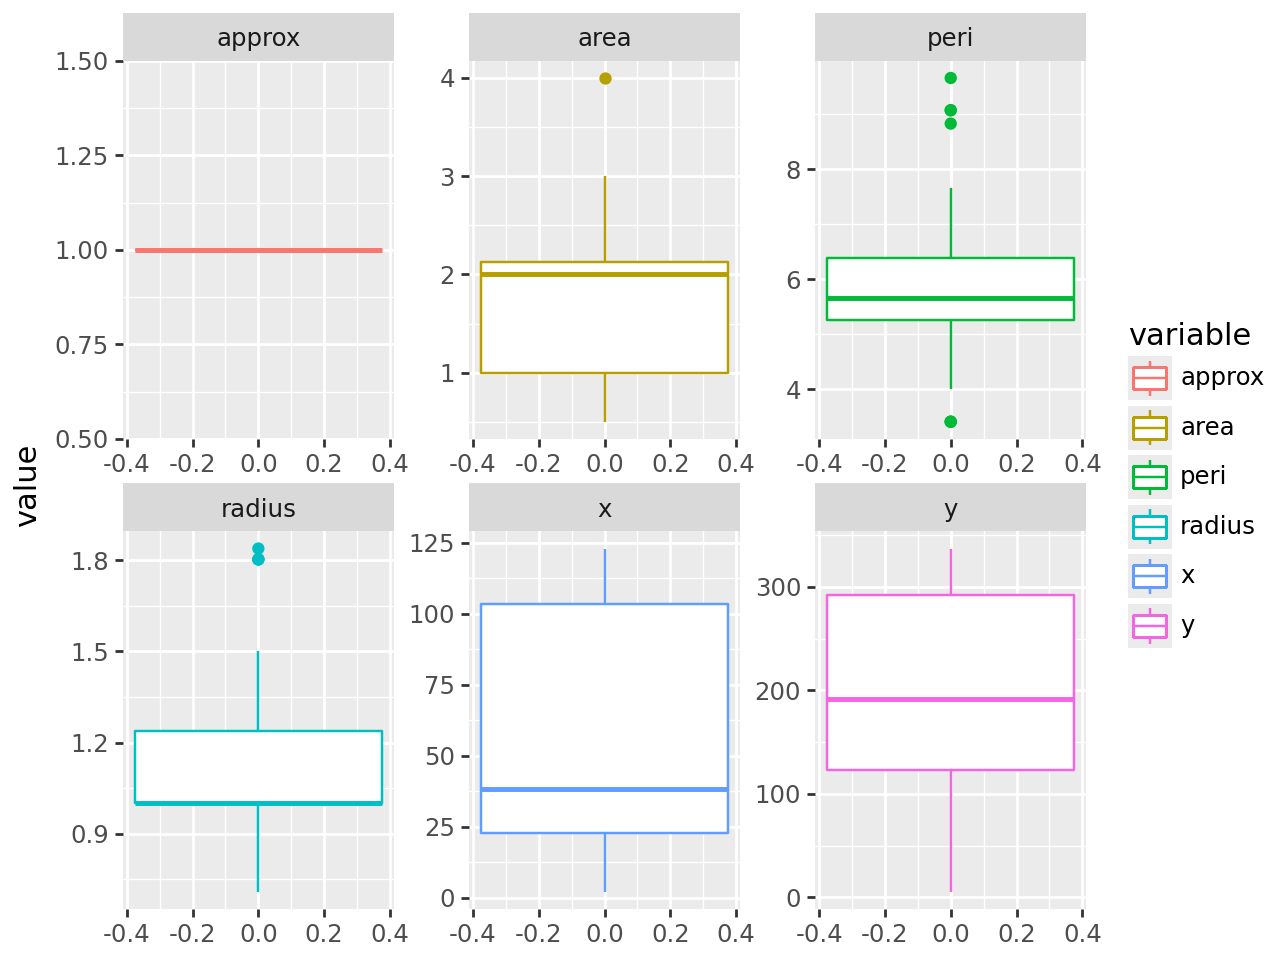

In [49]:
(
    ggplot(df.melt(), aes(y="value", color="variable"))
     + geom_boxplot() + facet_wrap("variable", ncol=3, scales="free")
     )